First 5 Rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset Shape: (545, 13)

Missing Values:
price               0
area                

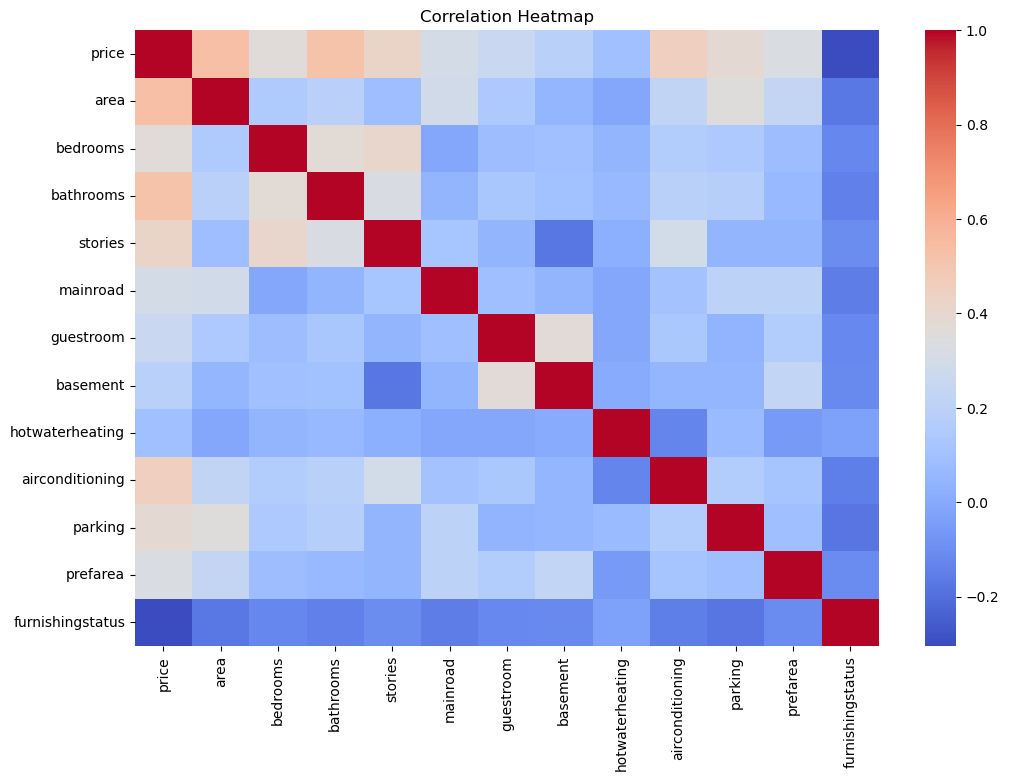


Model Evaluation
MAE : 979679.6912959903
MSE : 1771751116594.0344
RMSE: 1331071.4167895103
R2 Score: 0.6494754192267804


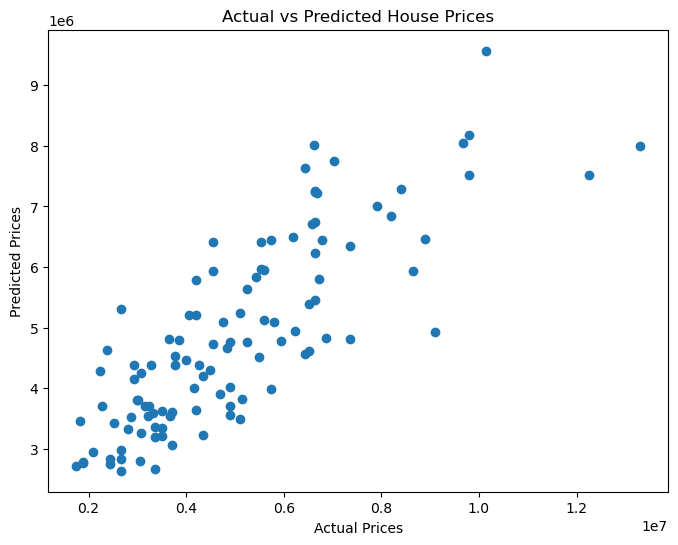

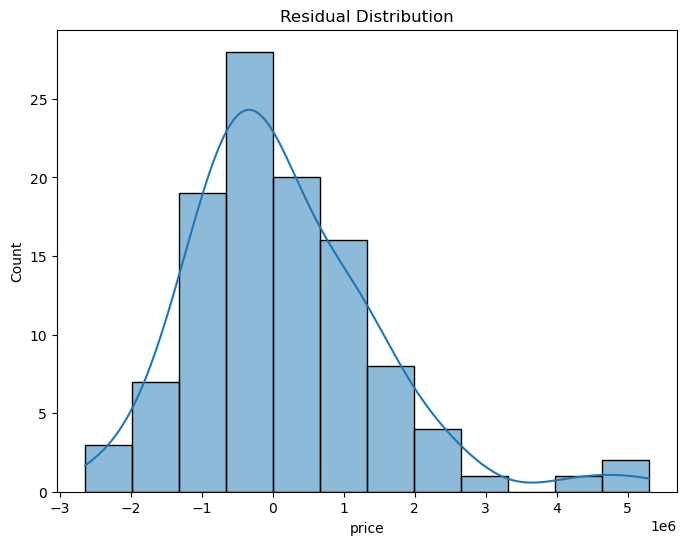


Sample Predictions:
     Actual Price  Predicted Price
316       4060000     5.203692e+06
77        6650000     7.257004e+06
360       3710000     3.062829e+06
90        6440000     4.559592e+06
493       2800000     3.332932e+06
209       4900000     3.563081e+06
176       5250000     5.645466e+06
249       4543000     6.413980e+06
516       2450000     2.755832e+06
426       3353000     2.668939e+06


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
df = pd.read_csv("Housing.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

# Convert categorical columns to numeric
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Features and Target
X = df.drop("price", axis=1)
y = df["price"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Residual Distribution
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# Sample Predictions
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

print("\nSample Predictions:")
print(results.head(10))